# Create the figure 1

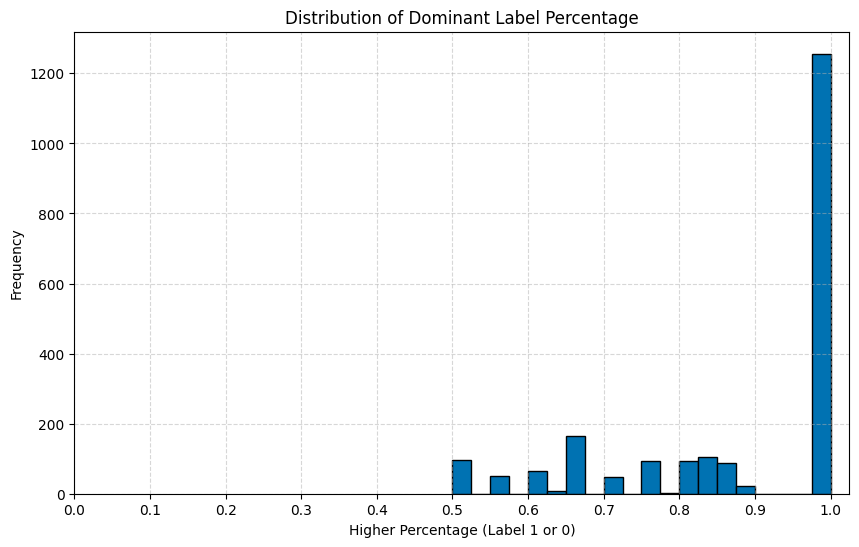

In [2]:
import pandas as pd
import numpy as np


with open("./ready_annotations.csv", "r") as f:
     annotations = pd.read_csv(f)

# organize the annotations by extract_id, and calculate the percentage of 1 or 0 in score column for each extract_id, then plot the distribution of higher persentage (label 1 or 0) for each extract_id (x-axis start from 0)
import matplotlib.pyplot as plt
annotations_grouped = annotations.groupby("extract_id")["score"].value_counts(normalize=True).unstack(fill_value=0)
annotations_grouped["higher_percentage"] = annotations_grouped.max(axis=1)
plt.figure(figsize=(10, 6))
plt.hist(annotations_grouped["higher_percentage"], bins=20, color='#0072B2', edgecolor="black")
plt.xlabel("Higher Percentage (Label 1 or 0)")
plt.ylabel("Frequency")
plt.title("Distribution of Dominant Label Percentage")
plt.xlim(0, 1.025)
plt.xticks(np.linspace(0, 1.0, 11))
plt.grid(True, linestyle='--', alpha=0.5)
out_pdf = "Figure 1: inter-human agreement.pdf"
plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
plt.show()


# Generate the samples that got consensus annotations.

In [3]:
# get all extract_id with higher percentage equals to 1
extract_ids_with_higher_percentage_1 = annotations_grouped[annotations_grouped["higher_percentage"] == 1].index.tolist()
print(len(extract_ids_with_higher_percentage_1))
# save the lines of extract_ids with higher percentage equals to 1 into a csv file
annotations_with_higher_percentage_1 = annotations[annotations["extract_id"].isin(extract_ids_with_higher_percentage_1)]
annotations_with_higher_percentage_1.to_csv("./ready_annotations_1254.csv", index=False)


1254
